In [2]:
import pandas as pd
import numpy as np

import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

from gnews import GNews
from datetime import datetime

import os
import time

from transformers import BertTokenizer,BertForSequenceClassification,pipeline,AutoTokenizer,AutoModelForSequenceClassification
import torch

In [2]:
'''gn = GNews(language='en', country='US', max_results=5)

# Top news
top = gn.get_top_news()

# Search by keyword
results = gn.get_news('artificial intelligence')

# By topic
tech_news = gn.get_news_by_topic('TECHNOLOGY')

# By location
india_news = gn.get_news_by_location('India')

# Full article
article = gn.get_full_article(results[0]['url'])
print(article.text))

def trim_csv_files(folder_path: str, output_folder: str = None):

    if output_folder is None:
        output_folder = folder_path
    else:
        os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(folder_path):
        if not filename.lower().endswith(".csv"):
            continue

        file_path = os.path.join(folder_path, filename)

        try:
            # Efficient read
            df_trimmed = pd.read_csv(file_path, nrows=201)

            save_path = os.path.join(output_folder, filename)
            df_trimmed.to_csv(save_path, index=False)

            print(f"Processed: {filename}")

        except Exception as e:
            print(f"Skipping {filename}: {e}")'''
'''texts = new_news.iloc[:, 1].tolist()
        results = self.pipe(texts, top_k=None)
        probs = [{d['label']: d['score'] for d in res} for res in results]

        probs_df = pd.DataFrame(probs)

        new_news = pd.concat([new_news.reset_index(drop=True), probs_df], axis=1)
        new_news['label'] = probs_df.idxmax(axis=1)
        new_news['sentiment_score']=new_news['positive'] - new_news['negative']
        self.df=new_news

        return self.df'''
'''def __init__(self,base_path:str = r"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\sentiment_gnews"):
        self.classifier = pipeline('text-classification',model="ProsusAI/finbert")
        self.base_path=base_path
        self.dfs=[]
        self.df=[]'''

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 38-39: truncated \UXXXXXXXX escape (2482668649.py, line 55)

In [3]:
class NewsAcquirer:
    def __init__(self,language:str = 'en' ,max_results:int = 100):
        self.gn=GNews(language=language,max_results=max_results)

    def acquire_news_keyword(self,topic:str):
          try:
            print(topic)
            _=pd.DataFrame(self.gn.get_news(topic))
            _['time_of_collection']=datetime.now().strftime('%Y-%m-%d %H:%M:%S')
            _['time_of_collection'] = pd.to_datetime(_['time_of_collection'],format='mixed',dayfirst=True)
            print(_.head())
            time.sleep(10)
            _['published date']=pd.to_datetime(_['published date'])
            _['date'] = _['time_of_collection'].dt.normalize()
            _['ticker']=topic
            return _
            del _
          except Exception as e:
              print(f'Error:{e}')
              pass

    def acquire_news_top(self):
        return self.gn.get_top_news()

    def acquire_news_topic(self,topic:str):
        return self.gn.get_news(topic)

    #drops all rows that present in old_news
    def filter_new_news(self,new_news:pd.DataFrame,old_news:pd.DataFrame):
        x=0
        for index,title in enumerate(new_news.iloc[:,0]):
            if title in old_news.iloc[:,0].values:
                new_news.drop(index=index,axis=1,inplace=True)
                x=x+1
            else:
                pass
        print('Total news dropped:',x)

class NewsRecorder:

    def __init__(self, base_path:str = r"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\sentiment_gnews"):
        self.base_path = base_path
        self.files = os.listdir(base_path)
        self.dfs=[]

    def _path_for(self, ticker: str) -> str:
        return os.path.join(self.base_path, f"{ticker}.csv")

    def record_news(self,new_news:pd.DataFrame,ticker:str,header:bool = True,mode:str = 'a'):
        new_news.to_csv(self._path_for(ticker=ticker),header=header,index=False,mode=mode)

    def load_all(self):
        for ticker in self.files:
             if not ticker.endswith('.csv'):
                continue
             temp = pd.read_csv(self.base_path+f'\\{ticker}')
             temp['ticker'] = ticker
             self.dfs.append(temp)

        return pd.concat(self.dfs, ignore_index=True)

class SentimentAnalyser:

    def __init__(self,base_path:str = r"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\sentiment_gnews"):
        self.model_name="distilbert-base-uncased-finetuned-sst-2-english"

        self.model = BertForSequenceClassification.from_pretrained(self.model_name)
        self.tokenizer = BertTokenizer.from_pretrained(self.model_name)

        self.base_path=base_path
        self.dfs=[]
        self.df=[]

    def _acquire_sentiment(self,new_news:pd.DataFrame):

        texts = new_news.iloc[:, 1].tolist()
        inputs = self.tokenizer(texts, return_tensors="pt", padding=True, truncation=True)


        all_probs = []
        all_logits = []

        label_map = self.model.config.id2label  # {0: 'positive', ...}

        batch_size=64

        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]

            inputs = self.tokenizer(batch_texts,return_tensors="pt",padding=True,truncation=True,max_length=128)

            with torch.no_grad():
                outputs = self.model(**inputs)

            logits = outputs.logits
            probs_tensor = torch.softmax(logits, dim=1)

            # process batch
            for j in range(len(batch_texts)):
                all_probs.append({label_map[k]: probs_tensor[j][k].item()for k in range(logits.shape[1])})

                all_logits.append({label_map[k] + '_logit': logits[j][k].item()for k in range(logits.shape[1])})

        # convert to DataFrame
        probs_df = pd.DataFrame(all_probs)
        logits_df = pd.DataFrame(all_logits)

        new_news = pd.concat([new_news.reset_index(drop=True), probs_df, logits_df], axis=1)
        new_news['label']= probs_df.idxmax(axis=1)
        print(new_news)
        new_news['sentiment_score'] = new_news['POSITIVE'] - new_news['NEGATIVE']
        new_news['sentiment_logit'] = new_news['POSITIVE_logit'] - new_news['NEGATIVE_logit']

        self.df = new_news
        return self.df


    def _acquire_sentiment_stats_market(self):
        market_sentiment = self.df.groupby('date').agg({'sentiment_score': ['mean', 'count', 'std'],'sentiment_logit': ['mean', 'std']})
        market_sentiment.columns = ['mean_sentiment', 'news_count', 'sentiment_volatility','mean_sentiment_logit', 'sentiment_volatility_logit']
        market_sentiment['Zscore']=(market_sentiment['mean_sentiment']-market_sentiment['mean_sentiment'].mean())/market_sentiment['sentiment_volatility']
        market_sentiment['Zscore_logit']=(market_sentiment['mean_sentiment_logit']-market_sentiment['mean_sentiment_logit'].mean())/market_sentiment['sentiment_volatility_logit']
        market_sentiment['sentiment_change'] = market_sentiment['mean_sentiment'].diff()
        market_sentiment['sentiment_change_logit'] = market_sentiment['mean_sentiment_logit'].diff()

        return market_sentiment

    def _acquire_sentiment_stats_tickers(self):
        ticker_sentiment = self.df.groupby(['date', 'ticker']).agg({'sentiment_score': ['mean', 'count','std'],'sentiment_logit': ['mean', 'std']})

        ticker_sentiment.columns = ['mean_sentiment', 'news_count','sentiment_volatility','mean_sentiment_logit','sentiment_volatility_logit']
        ticker_sentiment = ticker_sentiment.reset_index()
        ticker_sentiment['Zscore']=(ticker_sentiment['mean_sentiment']-ticker_sentiment['mean_sentiment'].mean())/ticker_sentiment['sentiment_volatility']
        ticker_sentiment['Zscore_logit']=(ticker_sentiment['mean_sentiment_logit']-ticker_sentiment['mean_sentiment_logit'].mean())/ticker_sentiment['sentiment_volatility_logit']
        ticker_sentiment['sentiment_change'] = ticker_sentiment.groupby('ticker')['mean_sentiment'].diff()
        ticker_sentiment['sentiment_change_logit'] = ticker_sentiment.groupby('ticker')['mean_sentiment_logit'].diff()

        return ticker_sentiment

    def acquire_sentiment_stats(self,loader:NewsRecorder):
        _df=loader.load_all()
        return self._acquire_sentiment(_df),self._acquire_sentiment_stats_market(),self._acquire_sentiment_stats_tickers()

class NewsPipeline:
    INDICES = ["Nifty 50", "Sensex", "S&P 500","Dow Jones Industrial Average", "NASDAQ Composite"]
    INDIAN_COMPANIES = ["Reliance Industries", "Tata Consultancy Services","HDFC Bank", "Infosys", "ICICI Bank"]
    US_COMPANIES = ["Apple Inc.", "Microsoft", "NVIDIA","Amazon", "Tesla", "Alphabet Inc."]

    def __init__(self, base_path: str = r"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\sentiment_gnews"):
        self.acquirer = NewsAcquirer()
        self.recorder = NewsRecorder(base_path)
        self.analyser = SentimentAnalyser()


    def _all_tickers(self):
        return self.INDICES + self.US_COMPANIES + self.INDIAN_COMPANIES

    def run_acquisition(self):
        for ticker in self._all_tickers():
            try:
                _tempdf=self.acquirer.acquire_news_keyword(topic=ticker)
                self.recorder.record_news(new_news=_tempdf,ticker=ticker,header=False)
            except Exception as e:
                print(f'Error at run_acquisition {e}')
                pass

    def sentiment_analysis(self):
        main_df,market_sentiment_df,ticker_sentiment_df = self.analyser.acquire_sentiment_stats(loader=self.recorder)
        return main_df,market_sentiment_df,ticker_sentiment_df


In [7]:
newspipe=NewsPipeline()

04/05/2026 03:08:12 PM - HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased-finetuned-sst-2-english/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"


In [6]:
newspipe.run_acquisition()

NameError: name 'newspipe' is not defined

In [4]:
newspipe=NewsPipeline()

04/05/2026 04:46:05 PM - HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased-finetuned-sst-2-english/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"


In [5]:
df,market_df,ticker_df=newspipe.sentiment_analysis()

                                                   title  \
0      Chip Selloff Deepens After Google Touts Memory...   
1      Alphabet Quietly Entered A Multibillion-Dollar...   
2      Meta and Google’s Addiction Verdict Turns the ...   
3      Alphabet Stock Gets a Boost From Waymo. Robo-T...   
4      1 Brilliant Growth Stock to Buy Before It Join...   
...                                                  ...   
14101  The Safest American Car On Sale Right Now Is N...   
14102  Tesla reports 358,000 first-quarter vehicle de...   
14103  Tesla Shares Drop After EV Sales Fall Short of...   
14104  Tesla’s Q1 Delivery Miss And Storage Slowdown ...   
14105  Tesla's Sales Struggles Are Improving, But Not...   

                                             description  \
0      Chip Selloff Deepens After Google Touts Memory...   
1      Alphabet Quietly Entered A Multibillion-Dollar...   
2      Meta and Google’s Addiction Verdict Turns the ...   
3      Alphabet Stock Gets a Boost From

In [6]:
df

,title,description,published date,url,publisher,time_of_collection,date,ticker,NEGATIVE,POSITIVE,NEGATIVE_logit,POSITIVE_logit,label,sentiment_score,sentiment_logit
0,Chip Selloff Deepens After Google Touts Memory...,Chip Selloff Deepens After Google Touts Memory...,"Thu, 26 Mar 2026 11:40:53 GMT",https://news.google.com/rss/articles/CBMijAFBV...,"{'href': 'https://finance.yahoo.com', 'title':...",2026-03-26 22:17:16,2026-03-26,Alphabet Inc..csv,0.481636,0.518364,-0.059686,0.013802,POSITIVE,0.036727,0.073487
1,Alphabet Quietly Entered A Multibillion-Dollar...,Alphabet Quietly Entered A Multibillion-Dollar...,"Wed, 25 Mar 2026 16:22:33 GMT",https://news.google.com/rss/articles/CBMipwFBV...,"{'href': 'https://seekingalpha.com', 'title': ...",2026-03-26 22:17:16,2026-03-26,Alphabet Inc..csv,0.475548,0.524452,0.016246,0.114132,POSITIVE,0.048904,0.097886
2,Meta and Google’s Addiction Verdict Turns the ...,Meta and Google’s Addiction Verdict Turns the ...,"Thu, 26 Mar 2026 09:00:07 GMT",https://news.google.com/rss/articles/CBMiuAFBV...,"{'href': 'https://www.bloomberg.com', 'title':...",2026-03-26 22:17:16,2026-03-26,Alphabet Inc..csv,0.475637,0.524363,0.024720,0.122250,POSITIVE,0.048727,0.097530
3,Alphabet Stock Gets a Boost From Waymo. Robo-T...,Alphabet Stock Gets a Boost From Waymo. Robo-T...,"Thu, 26 Mar 2026 14:49:00 GMT",https://news.google.com/rss/articles/CBMingNBV...,"{'href': 'https://www.barrons.com', 'title': ""...",2026-03-26 22:17:16,2026-03-26,Alphabet Inc..csv,0.511783,0.488217,0.070483,0.023342,NEGATIVE,-0.023566,-0.047141
4,1 Brilliant Growth Stock to Buy Before It Join...,1 Brilliant Growth Stock to Buy Before It Join...,"Tue, 24 Mar 2026 22:45:00 GMT",https://news.google.com/rss/articles/CBMilgFBV...,"{'href': 'https://www.fool.com', 'title': 'The...",2026-03-26 22:17:16,2026-03-26,Alphabet Inc..csv,0.470302,0.529698,-0.069589,0.049342,POSITIVE,0.059395,0.118930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14101,The Safest American Car On Sale Right Now Is N...,The Safest American Car On Sale Right Now Is N...,2026-04-03 19:00:11,https://news.google.com/rss/articles/CBMib0FVX...,"{'href': 'https://carbuzz.com', 'title': 'CarB...",2026-04-05 08:20:03,2026-04-05,Tesla.csv,0.475629,0.524371,0.014872,0.112433,POSITIVE,0.048742,0.097561
14102,"Tesla reports 358,000 first-quarter vehicle de...","Tesla reports 358,000 first-quarter vehicle de...",2026-04-02 13:26:00,https://news.google.com/rss/articles/CBMixgFBV...,"{'href': 'https://www.cnbc.com', 'title': 'CNBC'}",2026-04-05 08:20:03,2026-04-05,Tesla.csv,0.500021,0.499979,0.057289,0.057203,NEGATIVE,-0.000043,-0.000086
14103,Tesla Shares Drop After EV Sales Fall Short of...,Tesla Shares Drop After EV Sales Fall Short of...,2026-04-02 13:12:00,https://news.google.com/rss/articles/CBMikAFBV...,"{'href': 'https://www.businessinsider.com', 't...",2026-04-05 08:20:03,2026-04-05,Tesla.csv,0.492970,0.507030,0.034753,0.062876,POSITIVE,0.014061,0.028123
14104,Tesla’s Q1 Delivery Miss And Storage Slowdown ...,Tesla’s Q1 Delivery Miss And Storage Slowdown ...,2026-04-03 19:10:24,https://news.google.com/rss/articles/CBMimwFBV...,"{'href': 'https://finance.yahoo.com', 'title':...",2026-04-05 08:20:03,2026-04-05,Tesla.csv,0.506545,0.493455,0.092009,0.065827,NEGATIVE,-0.013090,-0.026181


In [7]:
market_df

,mean_sentiment,news_count,sentiment_volatility,mean_sentiment_logit,sentiment_volatility_logit,Zscore,Zscore_logit,sentiment_change,sentiment_change_logit
date,,,,,,,,,
2026-03-26,0.031965,1592,0.027025,0.063998,0.054159,0.017184,0.017149,NaN,NaN
2026-03-27,0.031485,1576,0.027407,0.063042,0.054927,-0.000543,-0.000508,-0.000479,-0.000957
2026-03-28,0.032714,1174,0.027465,0.065504,0.055050,0.044187,0.044224,0.001228,0.002462
2026-03-29,0.032828,1599,0.027415,0.065730,0.054942,0.048421,0.048417,0.000114,0.000226
2026-03-31,0.030741,1592,0.027311,0.061545,0.054719,-0.027795,-0.027868,-0.002087,-0.004185
2026-04-01,0.030549,1884,0.026732,0.061162,0.053558,-0.035565,-0.035622,-0.000192,-0.000383
2026-04-02,0.030759,1491,0.027348,0.061584,0.054801,-0.027115,-0.027106,0.000209,0.000422
2026-04-04,0.031290,1599,0.028560,0.062650,0.057239,-0.007374,-0.007331,0.000531,0.001066
2026-04-05,0.031172,1599,0.028337,0.062412,0.056792,-0.011594,-0.011581,-0.000118,-0.000238


In [8]:
ticker_df

,date,ticker,mean_sentiment,news_count,sentiment_volatility,mean_sentiment_logit,sentiment_volatility_logit,Zscore,Zscore_logit,sentiment_change,sentiment_change_logit
0,2026-03-26,Alphabet Inc..csv,0.025821,100,0.021824,0.051677,0.043690,-0.243625,-0.244173,NaN,NaN
1,2026-03-26,Amazon.csv,0.040810,100,0.019098,0.081693,0.038262,0.506448,0.505672,NaN,NaN
2,2026-03-26,Apple Inc..csv,0.040335,100,0.024729,0.080758,0.049549,0.371886,0.371614,NaN,NaN
3,2026-03-26,Dow Jones Industrial Average.csv,0.030916,100,0.022399,0.061883,0.044869,-0.009913,-0.010291,NaN,NaN
4,2026-03-26,HDFC Bank.csv,0.029290,100,0.022252,0.058622,0.044551,-0.083067,-0.083564,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
138,2026-04-05,Reliance Industries.csv,0.042001,100,0.024011,0.084099,0.048132,0.452411,0.451970,0.000820,0.001648
139,2026-04-05,S&P 500.csv,0.027930,100,0.026403,0.055901,0.052869,-0.121499,-0.121882,-0.000669,-0.001349
140,2026-04-05,Sensex.csv,0.017982,100,0.020434,0.035987,0.040909,-0.643853,-0.644320,0.001827,0.003655
141,2026-04-05,Tata Consultancy Services.csv,0.010369,100,0.028290,0.020745,0.056632,-0.734166,-0.734560,-0.002074,-0.004158


In [ ]:
path=r"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\sentiment_gnews"

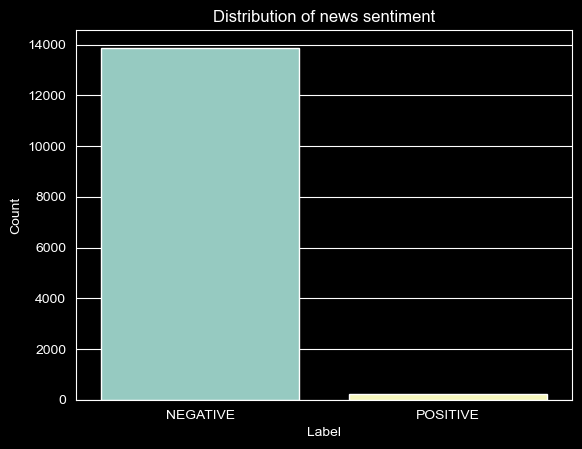

In [12]:
sns.countplot(data=df,x="label",hue="label")
plt.title('Distribution of news sentiment')
plt.ylabel('Count')
plt.xlabel('Label')
plt.show()

In [13]:
fig=go.Figure()
for time in df['date'].value_counts().index:
    fig.add_trace(go.Scatter(x=df[df['date']==time].index,y=df[df['date']==time]['sentiment_score'],mode='markers',name=str(time).rstrip('00:00:00')))
fig.show()